# Análise de Histogramas e Espaço de Cor HSV com OpenCV

**Este notebook explora técnicas de análise visual e melhoria de imagens.**

**Objetivo:** Praticar a manipulação de imagens no espaço de cores HSV (Hue, Saturation, Value) e analisar histogramas para extrair informações visuais relevantes.

**Principais tópicos abordados:**

- Conversão RGB → HSV;
- Separação dos canais Hue, Saturation e Value;
- Manipulação de saturação;
- Construção de histogramas;
- Análise de distribuição de pixels;
- Equalização de histogramas;
- Melhoria de contraste em imagens coloridas e tons de cinza.

## Imports

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

## 1. Conversão para HSV e Análise de Canais

**Tarefas:**
* Carregue a imagem colorida (**lenna_250.png**).
* Converta a imagem de BGR para HSV usando cv2.cvtColor().
* Separe os canais HSV (Hue, Saturation, Value) e exiba cada um em escala de cinza usando a biblioteca matplotlib.

### Carregue a imagem colorida (lenna_250.png)

In [2]:
path = '../data/imagem/'
# Carregar imagem
image_bgr = cv2.imread(path+'lenna_250.png')

### Converta a imagem de BGR para HSV usando cv2.cvtColor()

In [3]:
# Converter para RGB
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

# Converter para HSV
image_hsv = cv2.cvtColor(image_rgb,cv2.COLOR_RGB2HSV).astype(np.float32)

### Separe os canais HSV (Hue, Saturation, Value) e exiba cada um em escala de cinza usando a biblioteca matplotlib

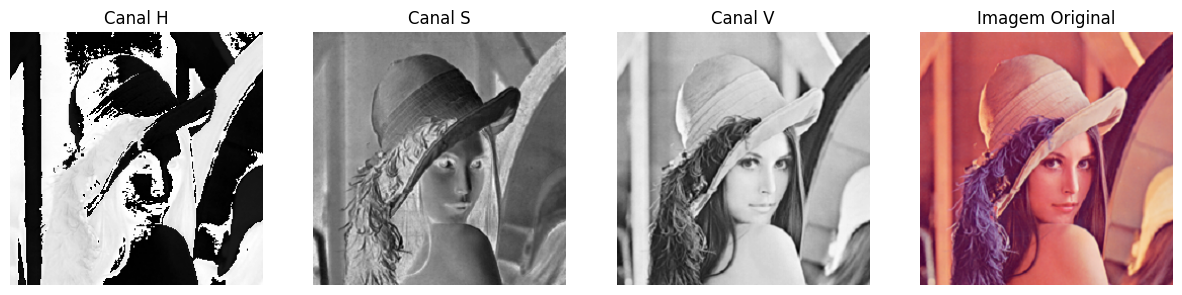

In [4]:
# Separar canais HSV
h, s, v = cv2.split(image_hsv)

# Exibir canais
fig, ax = plt.subplots(1, 4, figsize=(15, 5))

ax[0].imshow(h, cmap='gray')
ax[0].set_title('Canal H')
ax[0].axis('off')

ax[1].imshow(s, cmap='gray')
ax[1].set_title('Canal S')
ax[1].axis('off')

ax[2].imshow(v, cmap='gray')
ax[2].set_title('Canal V')
ax[2].axis('off')

ax[3].imshow(image_rgb)
ax[3].set_title('Imagem Original')
ax[3].axis('off')
    
plt.show()

**Continuação do problema 1.**

* Modifique apenas o canal Saturation (S) com +30% do seu valor e reconverter para RGB
* Exiba o resultado da imagem modificado com a imagem original. 

### Modifique apenas o canal Saturation (S) com +30% do seu valor e reconverter para RGB

In [5]:
img_hsv_sat = image_hsv.copy()

# Ajustar Saturação (S) - intervalo de 0 a 255
saturacao = 30
fator_s = (saturacao / 100) * 255

# aumentando a saturacao
img_hsv_sat[:, :, 1] = np.clip(img_hsv_sat[:, :, 1] + fator_s, 0, 255)

# Converter de volta para uint8 e para RGB
img_sat_rgb = img_hsv_sat.astype(np.uint8)

# Converter para padrão RGB
img_modificada = cv2.cvtColor(img_sat_rgb, cv2.COLOR_HSV2RGB)

### Exiba o resultado da imagem modificado com a imagem original

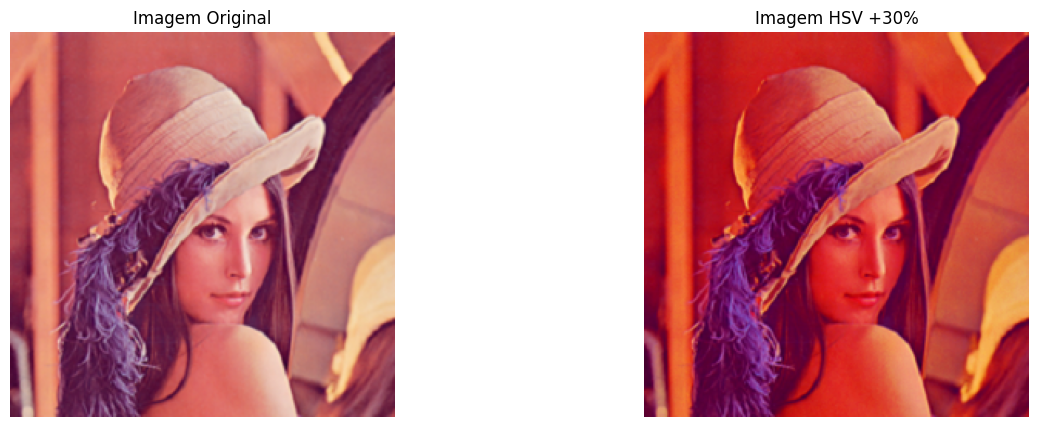

In [6]:
# Exibir imagem modificado com a imagem original
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ax[0].imshow(image_rgb)
ax[0].set_title('Imagem Original')
ax[0].axis('off')

ax[1].imshow(img_modificada)
ax[1].set_title('Imagem HSV +30%')
ax[1].axis('off')

plt.show()

## 2. Análise de Histogramas

**Tarefas:**

* Calcule o histograma do canal Hue (H) usando `cv2.calcHist()`.
* Plote o histograma usando matplotlib.
* Identifique picos no histograma (cores dominantes).
* Compare o histograma de Hue (HSV) com o histograma do canal Blue (RGB).

*Obs.: Utilize a imagem carregada do enunciado anterior (**lenna_250.png**)*

## Calcular histograma do canal Hue (Matiz)

In [7]:
# cv2.calcHist(images, channels, mask, histSize, ranges)
# --> images --> A função aceita múltiplas imagens, por isso exige lista
# --> channels --> Índice do canal a ser analisado --> Como img_b já é uma imagem de canal único, só existe o canal 0
# --> mask --> Máscara opcional para selecionar pixels --> None -->  usa todos os pixels da imagem
# --> histSize --> Número de bins (intervalos) --> Divide o espaço de intensidades em 180 partes
# --> ranges --> Intervalo de valores considerados --> Saturação no OpenCV vai 0 a 180
hist_hue = cv2.calcHist([h],[0], None, [180],[0,180])

## Plote o histograma usando matplotlib.

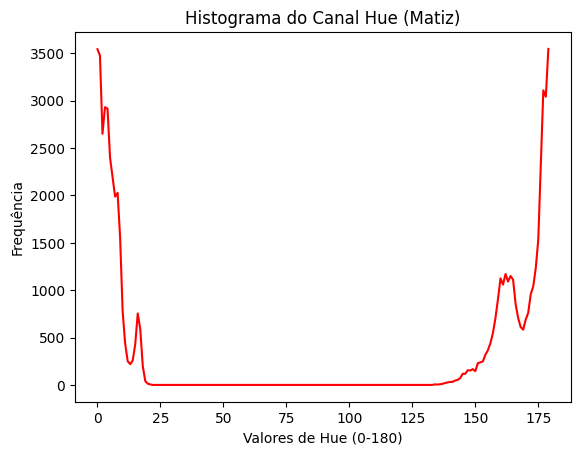

In [8]:
# Plotar histograma
plt.plot(hist_hue, color='r')  
plt.title("Histograma do Canal Hue (Matiz)")  
plt.xlabel("Valores de Hue (0-180)")  
plt.ylabel("Frequência")  
plt.show()  

## Identifique picos no histograma (cores dominantes).

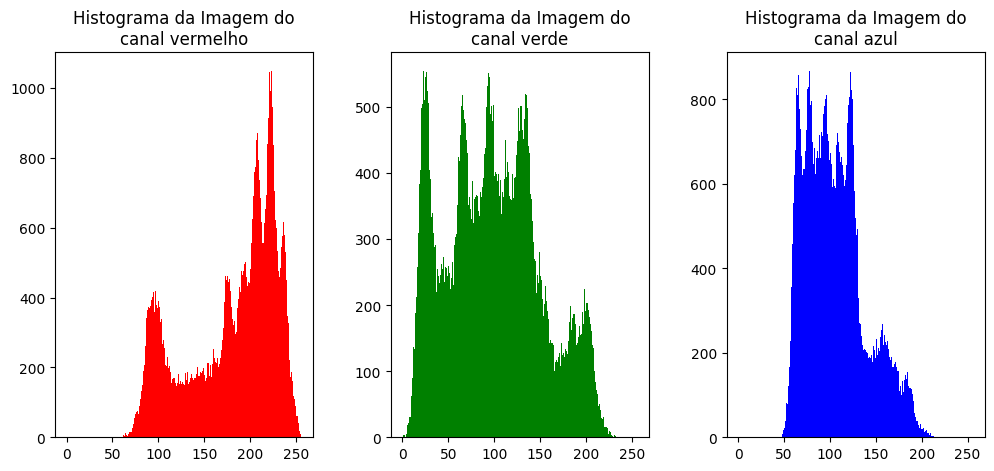

In [9]:
# Separando os canais da imagem rgb
img_r, img_g, img_b = cv2.split(image_rgb)

plt.figure(figsize=(12,5))

plt.subplot(1,3,1)
plt.hist(img_r.ravel(), bins=256, range=(0,256), color='red')
plt.title('Histograma da Imagem do\ncanal vermelho')

plt.subplot(1,3,2)
plt.hist(img_g.ravel(), bins=256, range=(0,256), color='green')
plt.title('Histograma da Imagem do\ncanal verde')

plt.subplot(1,3,3)
plt.hist(img_b.ravel(), bins=256, range=(0,256), color='blue')
plt.title('Histograma da Imagem do\ncanal azul')

plt.subplots_adjust(wspace=0.3, hspace=0.1)

plt.show()

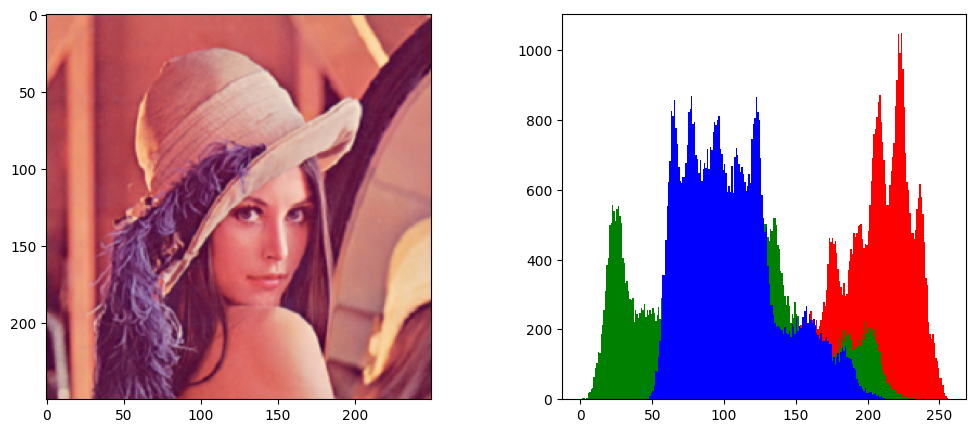

In [10]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(image_rgb)

plt.subplot(1,2,2)
plt.hist(img_r.ravel(), bins=256, range=(0,256), color='red')
plt.hist(img_g.ravel(), bins=256, range=(0,256), color='green')
plt.hist(img_b.ravel(), bins=256, range=(0,256), color='blue')

plt.subplots_adjust(wspace=0.3, hspace=0.1)

plt.show()

## Compare o histograma de Hue (HSV) com o histograma do canal Blue (RGB)

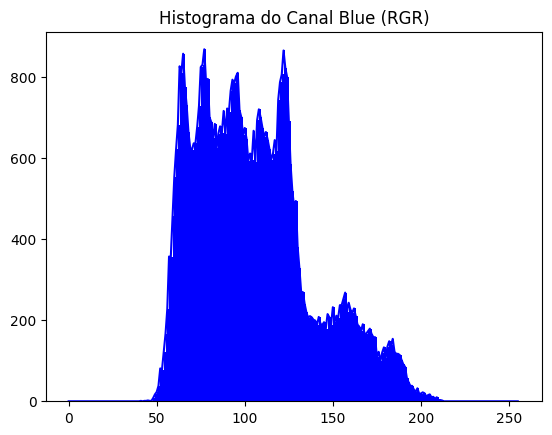

In [11]:
# Histograma do canal Blue (RGB)
blue_channel = plt.hist(img_b.ravel(), bins=256, range=(0,256), color='blue')
hist_blue = cv2.calcHist([img_b], [0], None, [256], [0,256])

plt.plot(hist_blue, color='b')  
plt.title("Histograma do Canal Blue (RGR)")  
plt.show()

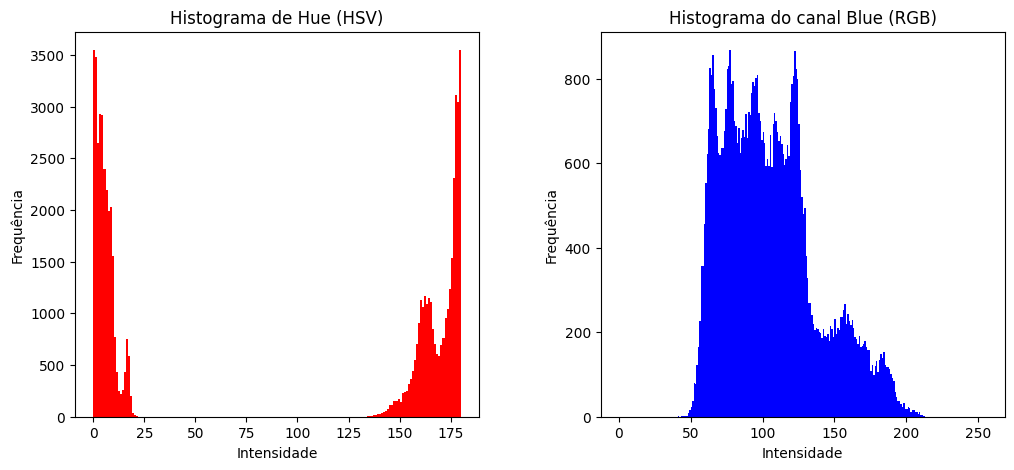

In [12]:
# Comparando os Histogramas lado a lado
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(h.ravel(), bins=180, range=(0,180), color='red')
plt.xlabel('Intensidade')
plt.ylabel('Frequência')
plt.title('Histograma de Hue (HSV)')
#plt.imshow(image_rgb)

plt.subplot(1,2,2)
plt.hist(img_b.ravel(), bins=256, range=(0,256), color='blue')
plt.xlabel('Intensidade')
plt.ylabel('Frequência')
plt.title('Histograma do canal Blue (RGB)')

plt.subplots_adjust(wspace=0.3, hspace=0.1)

plt.show()

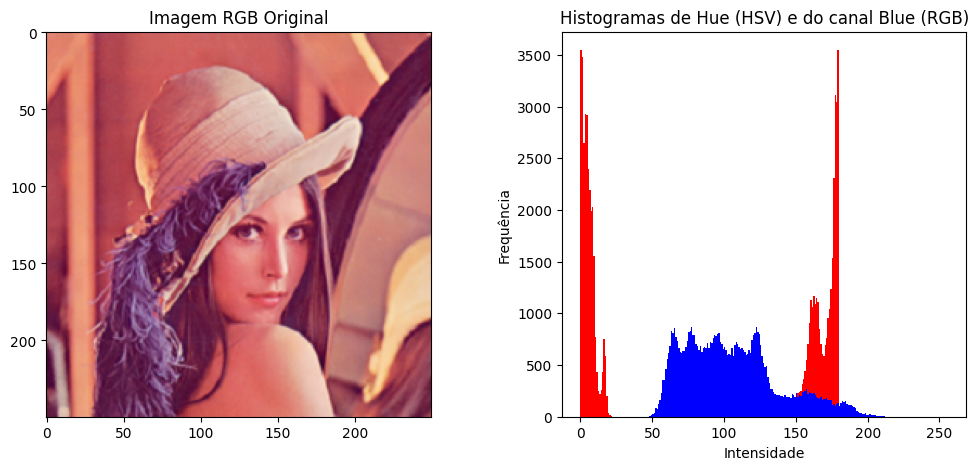

In [13]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(image_rgb)
plt.title('Imagem RGB Original')


plt.subplot(1,2,2)
plt.hist(h.ravel(), bins=180, range=(0,180), color='red')
plt.hist(img_b.ravel(), bins=256, range=(0,256), color='blue')
plt.xlabel('Intensidade')
plt.ylabel('Frequência')
plt.title('Histogramas de Hue (HSV) e do canal Blue (RGB)')

plt.subplots_adjust(wspace=0.3, hspace=0.1)

plt.show()

## 3. Equalização de Histograma em Imagens Monocromáticas

**Objetivo:**

Praticar a manipulação de histogramas para melhorar o contraste em imagens em tons de cinza, compreendendo o impacto visual da equalização.

**Tarefas:**

* Carregue uma imagem (**lena_cinza.png**) em escala de cinza..
* Calcule e plote o histograma original usando `cv2.calcHist()` e matplotlib, respectivamente.
* Aplique equalização de histograma usando `cv2.equalizeHist()`.
* Plote o histograma equalizado e compare sua distribuição com o original.
* Exiba a imagem antes e depois da equalização.

### Carregue uma imagem (lena_cinza.png) em escala de cinza

Imagem apenas em escala de cinza (400, 395)


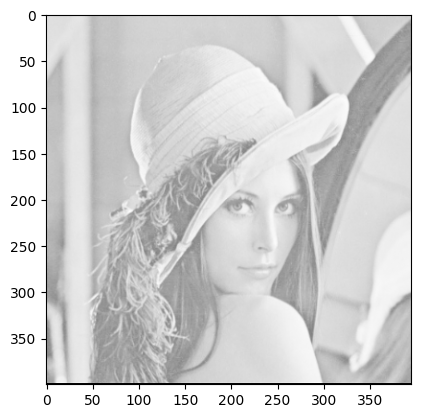

In [14]:
# Carregando a imagem BGR em escala de cinza
img_gray = cv2.imread(path+'lena_cinza.png', cv2.IMREAD_GRAYSCALE)

# shape da imagem com apenas 1 canal
print('Imagem apenas em escala de cinza', img_gray.shape)

# Imagem em escala de cinca
plt.imshow(img_gray, cmap='gray')
plt.show()

### Calcule e plote o histograma original usando cv2.calcHist() e matplotlib, respectivamente.

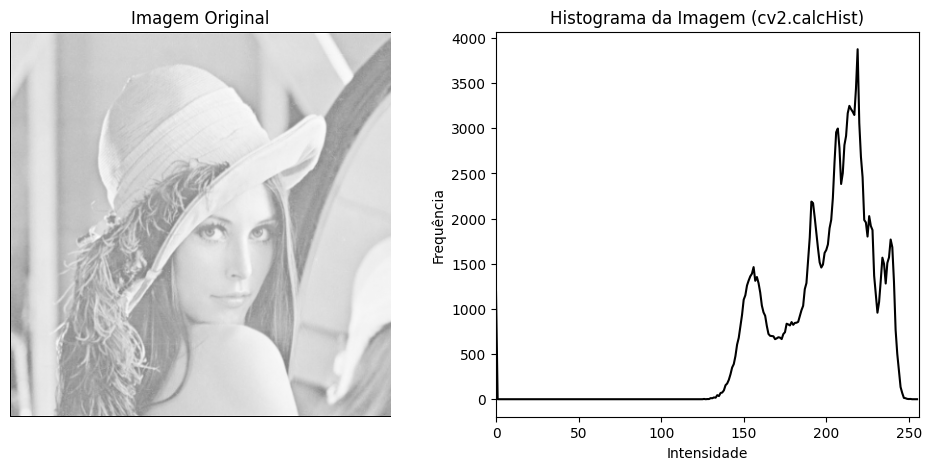

In [15]:
# Calcular histograma com OpenCV
hist = cv2.calcHist([img_gray], [0], None, [256], [0, 256])

# Plot
plt.figure(figsize=(12,5))

# Imagem
plt.subplot(1,2,1)
plt.imshow(img_gray, cmap='gray')
plt.title('Imagem Original')
plt.axis('off')

# Histograma
plt.subplot(1,2,2)
plt.plot(hist, color='black')
plt.title('Histograma da Imagem (cv2.calcHist)')
plt.xlabel('Intensidade')
plt.ylabel('Frequência')
plt.xlim([0,256])

plt.show()

### Aplique equalização de histograma usando cv2.equalizeHist()

In [16]:
# Aplicando equalização
img_equalizada = cv2.equalizeHist(img_gray)

### Plote o histograma equalizado e compare sua distribuição com o original.

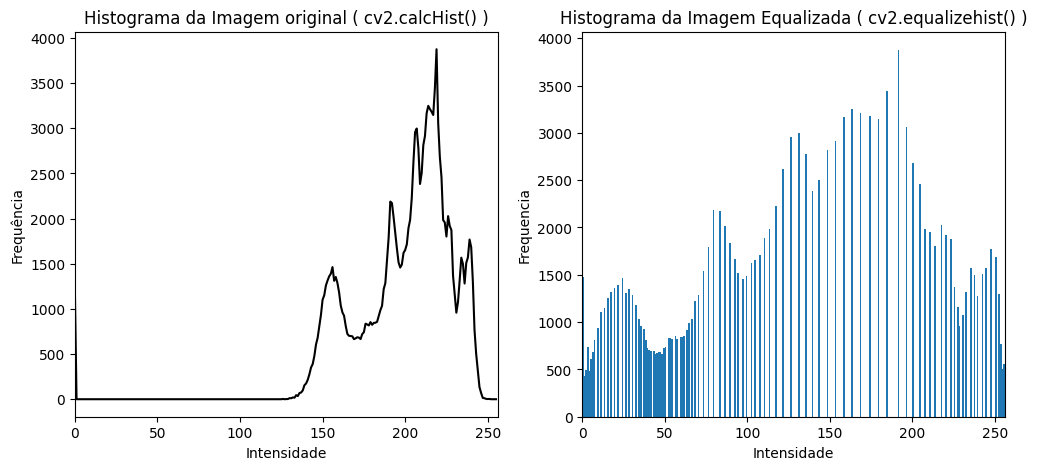

In [17]:
# Plot
plt.figure(figsize=(12,5))

# histograma original
plt.subplot(1,2,1)
plt.plot(hist, color='black' )

plt.title('Histograma da Imagem original ( cv2.calcHist() )')
plt.xlabel('Intensidade')
plt.ylabel('Frequência')
plt.xlim([0,256])

# histograma equalizado
plt.subplot(1,2,2)
#plt.plot(img_equalizada,color='red')
plt.hist(img_equalizada.ravel(), bins=256, range=(0,256))
plt.title('Histograma da Imagem Equalizada ( cv2.equalizehist() )')
plt.xlabel('Intensidade')
plt.ylabel('Frequencia')
plt.xlim([0,256])

plt.show();

### Exiba a imagem antes e depois da equalização.

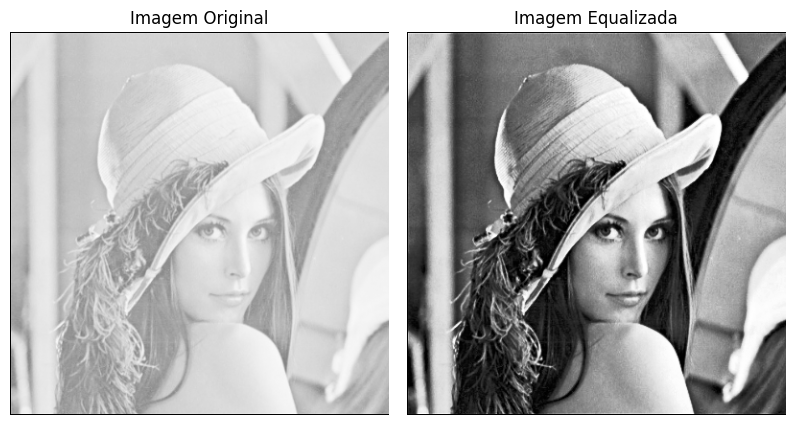

In [18]:
plt.figure(figsize=(10,8))

plt.subplot(1,2,1)
plt.imshow(img_gray, cmap='gray')
plt.title('Imagem Original')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(img_equalizada, cmap='gray')
plt.title('Imagem Equalizada')
plt.axis('off')

plt.subplots_adjust(wspace=0.05, hspace=0.2)
plt.show()

## 4. Equalização de Histograma em Imagens Coloridas no Espaço HSV

**Objetivo**

Praticar a equalização de histograma em imagens coloridas preservando as informações de cor, através da manipulação do canal de intensidade (Value) no espaço HSV.

**Tarefas**

* Carregamento e Visualização Inicial
    * Carregue a imagem **lenna_250.png** usando OpenCV.
    * Converta a imagem BGR para RGB.
    * Exiba a imagem convertida RGB e seu histograma nos canais R, G e B.

* Conversão para Espaço HSV
    * Converta a imagem RGB para o espaço de cores HSV.    

* Equalização do Canal V (Value)
    * Equalize apenas o canal V (intensidade/luminância) usando cv2.equalizeHist().
    * Converta a imagem de volta para RGB após a equalização.

* Visualização dos Resultados
    * Exiba a imagem convertida RGB equalizada e seu respectivo histograma nos canais R, G e B.

### Carregamento e Visualização Inicial ##

In [19]:
# Carregar imagem
img_bgr = cv2.imread(path+'lenna_250.png')

# Converter para RGB
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Sepera os canais RGB
img_r, img_g, img_b = cv2.split(img_rgb)

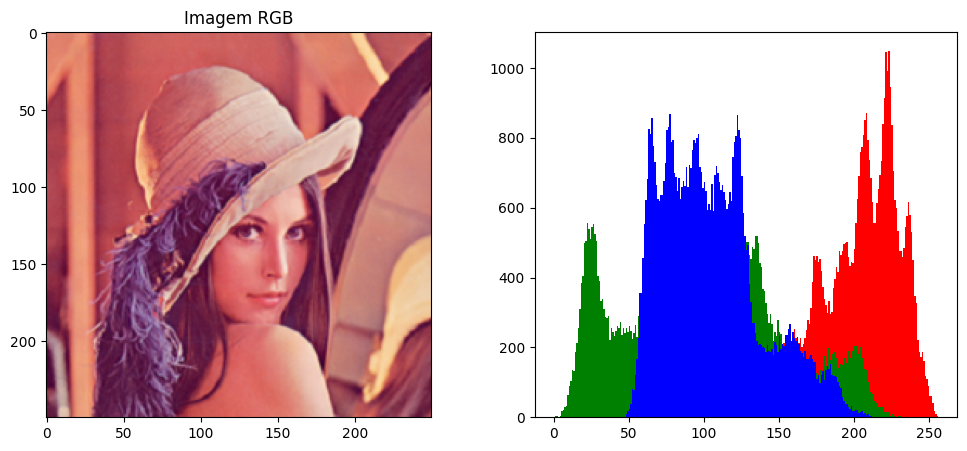

In [20]:
# Exibe a imagem convertida RGB e seu histograma nos canais R, G e B.

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.title('Imagem RGB')

plt.subplot(1,2,2)
plt.hist(img_r.ravel(), bins=256, range=(0,256), color='red')
plt.hist(img_g.ravel(), bins=256, range=(0,256), color='green')
plt.hist(img_b.ravel(), bins=256, range=(0,256), color='blue')

plt.show()

### Conversão para Espaço HSV

In [21]:
## Conversão para Espaço HSV ##

# Converter para HSV
img_hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)

# Separar canais HSV
h, s, v = cv2.split(img_hsv)

### Equalização do Canal V (Value)

In [22]:
# Equalizar apenas o canal de intensidade v
img_hsv[:,:,2] = cv2.equalizeHist(img_hsv[:,:,2])

# Converta a imagem de volta para RGB após a equalização.
img_equal_rgb = cv2.cvtColor(img_hsv, cv2.COLOR_HSV2RGB)

### Visualização dos Resultados

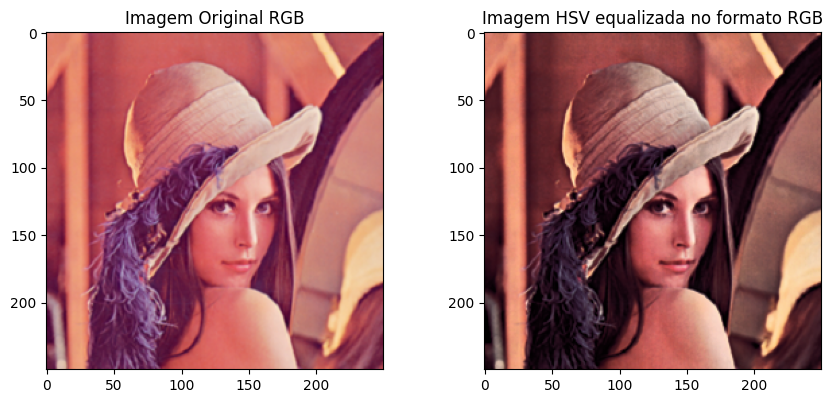

In [23]:
# Exibe a imagem convertida RGB 
plt.figure(figsize=(10,8))

plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.title('Imagem Original RGB')

plt.subplot(1,2,2)
plt.imshow(img_equal_rgb)
plt.title('Imagem HSV equalizada no formato RGB')

plt.subplots_adjust(wspace=0.3, hspace=0.1)
plt.show();

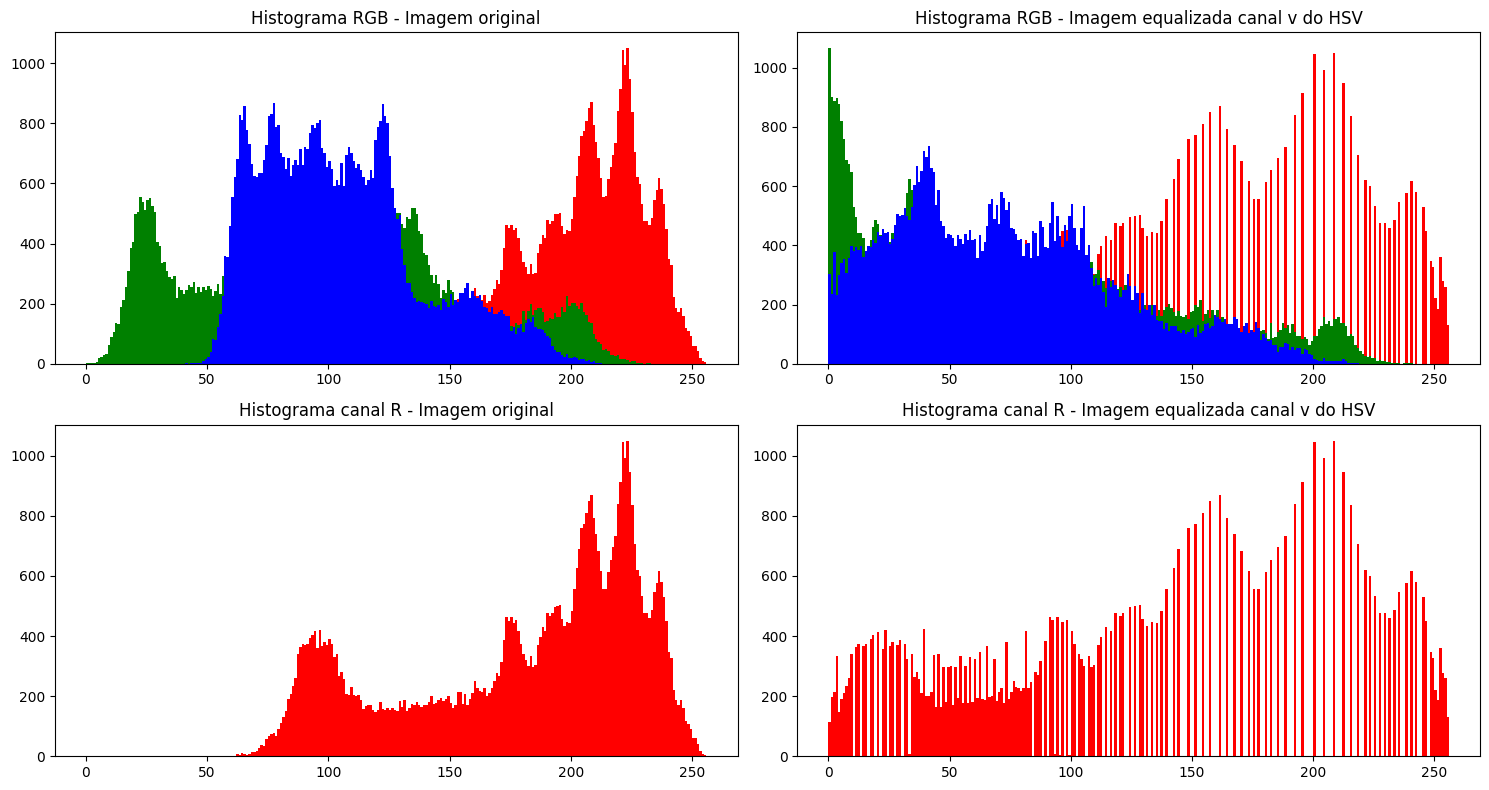

In [24]:
# Separa os canais RGB da imagem equalizada
r_eq, g_eq, b_eq = cv2.split(img_equal_rgb)


plt.figure(figsize=(15,8))

plt.subplot(2,2,1)
plt.hist(img_r.ravel(), bins=256, range=([0,256]), color='red' )
plt.hist(img_g.ravel(), bins=256, range=([0,256]), color='green')
plt.hist(img_b.ravel(), bins=256, range=([0,256]), color='blue')
plt.title('Histograma RGB - Imagem original')


plt.subplot(2,2,2)
# Exibe o histograma nos canais R, G e B.
plt.hist(r_eq.ravel(), bins=256, range=(0,256),color='red')
plt.hist(g_eq.ravel(), bins=256, range=(0,256),color='green')
plt.hist(b_eq.ravel(), bins=256, range=(0,256),color='blue')
plt.title('Histograma RGB - Imagem equalizada canal v do HSV')

plt.subplot(2,2,3)
plt.hist(img_r.ravel(), bins=256, range=([0,256]), color='red' )
plt.title('Histograma canal R - Imagem original')

plt.subplot(2,2,4)
plt.hist(r_eq.ravel(), bins=256, range=(0,256),color='red')
plt.title('Histograma canal R - Imagem equalizada canal v do HSV')

plt.tight_layout()
plt.show()